# Kuiper statistic analysis

In this notebook, I compare the Kuiper statistics between daily maximum values / anomalies and bootstrapped Kuiper statistics from both stationary and fitted parameter values. The goal is to show that all of these are too similar to rule out, which lets us use a GEV distribution to characterize trends in extreme temperatures.

In [19]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from evt_heat_waves.config import DATA_ROOT, FIGS_PATH
from evt_heat_waves.utils import compute_ecdf

# import custom stuff
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.utils import make_figure_filename

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

save_figs = True

In [55]:
data_type = 'annmean'
tmin = 1979
ex_type = 'min'
fit = 'stat'

In [56]:
if data_type != 'raw':
    anom_type = f'anom_{data_type}'
else:
    anom_type = data_type

In [57]:
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'gev' / f'era5_t2m_annual_{ex_type}_1deg_landonly_gev_{fit}_TMIN{tmin}_{data_type}_kuiper.nc', engine='netcdf4')
ds_boot = xr.open_dataset(DATA_ROOT / 'stats' /f'bootstrapped_ks_{tmin}.nc', engine='netcdf4')

## Kuiper statistic CDFs

In [58]:
def plot_kuiper_max_min_ecdf(ds_max, ds_boot, k_type, k_min, k_max, xlim=False,
                             filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < k_max)]
    syn_k_max = syn_k_max[(syn_k_max >= 0.0) & (syn_k_max < k_max)]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    obs_k_max_cdf, obs_k_max_probs = compute_ecdf(obs_k_max, extend_lower=True, extend_upper=False)
    syn_k_max_cdf, syn_k_max_probs = compute_ecdf(syn_k_max, extend_lower=True, extend_upper=False)
    
    boot_k_cdf, boot_k_probs = compute_ecdf(boot_k, extend_lower=True, extend_upper=True,
                                            ub=max(max(syn_k_max_cdf), max(obs_k_max_cdf)))

    # create figure
    fig, ax = plt.subplots(1, figsize=(8, 6), constrained_layout=True)

    # first panel: maximum temperatures
    ax.plot(obs_k_max_cdf, obs_k_max_probs, label='ERA5',
              linewidth=3)
    ax.plot(syn_k_max_cdf, syn_k_max_probs, label='Bootstrapped,\nfitted parameters',
              linewidth=2, linestyle='dashed')
    ax.plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\narbitrary parameters',
              linewidth=2, linestyle='dotted')
    
    ax.set_xlabel('Kuiper statistic')
    ax.legend(loc='lower right')
    
    ax.set_ylabel('CDF')

    if xlim:
        ax.set_xlim((k_min, k_max))

    # add labels
    # label physical distance in and down:
    #trans = mtransforms.ScaledTranslation(0, 0.0, fig.dpi_scale_trans)
    #ax.text(0.05, 0.97, 'A', transform=ax.transAxes + trans, fontsize=20, fontweight='bold',
    #        verticalalignment='top', bbox=dict(facecolor='none', edgecolor='none', pad=1))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print(f'Figure saved to: {make_figure_filename(*filename_args)}')

Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-21-kuiper_min_anom_annmean_tmin1979.png


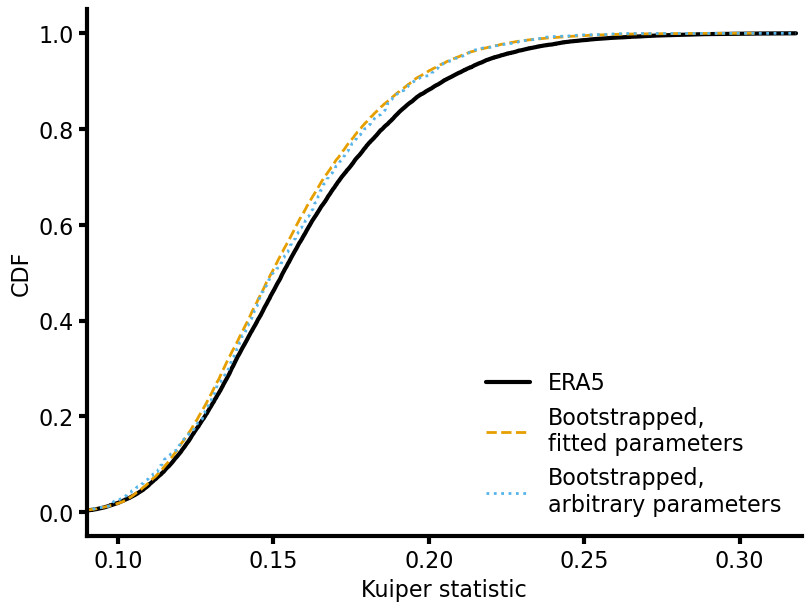

In [59]:
plot_kuiper_max_min_ecdf(ds_max, ds_boot, anom_type, k_min=0.09, k_max=0.32,
                         xlim=True, filename_args=[f'kuiper_{ex_type}_{anom_type}_tmin{tmin}', FIGS_PATH, 'png'])
plt.show()